# <center > Introduction to Neural Networks

**Assignment**: 2

**Group 3**: Object Detection with YOLOv5 on Pascal VOC 2012

March 2026

***
***

# 1. Libraries

In [2]:
import os
import random
import cv2
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as T
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import ToTensor

***
***

# 2 - Data Preparation

## 2 . 1 -  Importing Dataset ([Roboflow-Pascal-VOC-2012-v1](https://public.roboflow.com/ds/svpFeQVNQl?key=NHCMBvSdO5) train dataset)
The zip file contains distinct folders for `images` and `labels` so we will extract the metatdatas with the help of `torch.utils.data.Dataset`

In [3]:

class YOLODataset(Dataset):
    def __init__(self, img_dir, label_dir, transforms=None):
        self.img_dir = img_dir
        self.label_dir = label_dir
        self.transforms = transforms
        self.images = os.listdir(img_dir)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.images[idx])
        label_path = os.path.join(self.label_dir, self.images[idx].replace(".jpg", ".txt"))

        # Load image
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        # Load annotations
        boxes = []
        with open(label_path, "r") as f:
            for line in f.readlines():
                class_label, x, y, w, h = map(float, line.strip().split())
                boxes.append([class_label, x, y, w, h])

        if self.transforms:
            image = self.transforms(image)
        return image, torch.tensor(boxes)

## 2 . 2 - DataLoader

A custom `collate_fn` is needed because images in the same batch can have different numbers of bounding boxes. The default PyTorch collate tries to stack all targets into a single tensor, which fails when their lengths differ, our function keeps targets as a list instead.

In [57]:
def collate_fn(batch):
    images, targets = zip(*batch)
    return torch.stack(images, 0), list(targets)



train_dataset = YOLODataset(
    img_dir="Pascal VOC 2012.v1/train/images",
    label_dir="Pascal VOC 2012.v1/train/labels",
    transforms=T.ToTensor()
)


val_dataset = YOLODataset(
    img_dir="Pascal VOC 2012.v1/valid/images",
    label_dir="Pascal VOC 2012.v1/valid/labels",
    transforms=T.ToTensor()
)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False, collate_fn=collate_fn)

print(f"Training samples  : {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")

Training samples  : 13690
Validation samples: 3422


## 2 . 3 - Sample Visualisation

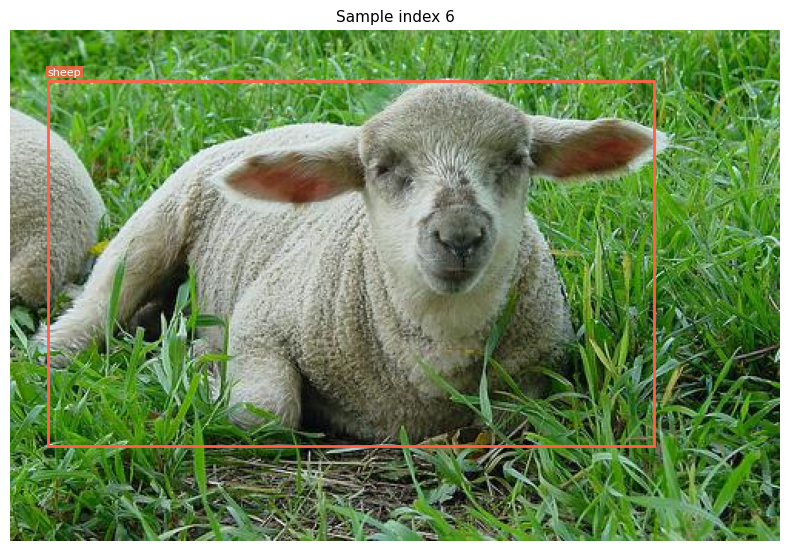

In [58]:

# Order can be seen in the .yaml file
VOC_CLASSES = [
    'aeroplane', 'bicycle', 'bird', 'boat', 'bottle',
    'bus', 'car', 'cat', 'chair', 'cow',
    'diningtable', 'dog', 'horse', 'motorbike', 'person',
    'pottedplant', 'sheep', 'sofa', 'train', 'tvmonitor'
]

def show_image_with_boxes(dataset, idx):
    image, boxes = dataset[idx]
    img = image.permute(1, 2, 0).numpy()
    img_h, img_w = img.shape[:2]

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.imshow(img)

    for box in boxes:
        cls, cx, cy, w, h = box.tolist()
        x1 = (cx - w / 2) * img_w
        y1 = (cy - h / 2) * img_h
        rect = plt.Rectangle((x1, y1), w * img_w, h * img_h,
                              linewidth=2, edgecolor='tomato', facecolor='none')
        ax.add_patch(rect)
        ax.text(x1, y1 - 4, VOC_CLASSES[int(cls)],
                fontsize=8, color='white',
                bbox=dict(facecolor='tomato', alpha=0.8, pad=1, edgecolor='none'))

    ax.axis('off')
    ax.set_title(f"Sample index {idx}", fontsize=11)
    plt.tight_layout()
    plt.show()

show_image_with_boxes(train_dataset, 6)

## 2 . 4 - Class Distribution

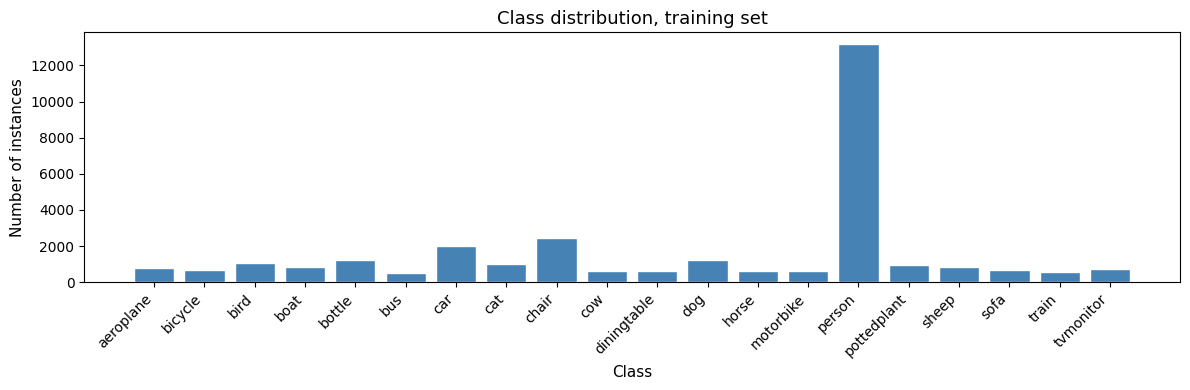

In [8]:
from collections import Counter

class_counts = Counter()
for _, boxes in train_dataset:
    for box in boxes:
        class_counts[int(box[0].item())] += 1

labels = [VOC_CLASSES[i] for i in range(20)]
counts = [class_counts.get(i, 0) for i in range(20)]

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(labels, counts, color='steelblue', edgecolor='white')
ax.set_xlabel("Class", fontsize=11)
ax.set_ylabel("Number of instances", fontsize=11)
ax.set_title("Class distribution, training set", fontsize=13)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Here we notice the Class Imbalance towards `person`**

***
***

# 3. Model Architecture

YOLO frames object detection as a single regression problem: one forward pass predicts all boxes and class probabilities at once. The network has three parts, a **backbone** that reads the image and extracts features, a **detection head** that turns those features into box predictions, and a **loss function** that guides training. We build each from scratch.

## 3 . 1 - `ConvBlock` (helper class):

- Neuron processing: convolution, batch normalization, activation (Leaky ReLU).

- YOLO uses Leaky ReLU instead of regular ReLU because it allows a small gradient for negative inputs rather than zeroing them out entirely, which helps with vanishing gradients in deep nets.

In [59]:
class ConvBlock(nn.Module):
    """A block of Conv2D -> BatchNorm -> ReLU."""
    def __init__(self, in_channels, out_channels, kernel_size, stride, padding):
        super(ConvBlock, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding)
        self.bn = nn.BatchNorm2d(out_channels)
        self.act = nn.LeakyReLU()

    def forward(self, x):
        return self.act(self.bn(self.conv(x)))

## 3 . 2 - `YOLOBackbone` (Feature extraction) 
Stacked convolutional blocks with **max-pooling** to extract features from the input image.

In [61]:
class YOLOBackbone(nn.Module):
    def __init__(self):
        super(YOLOBackbone, self).__init__()
        self.layers = nn.Sequential(
            ConvBlock(3, 32, kernel_size=3, stride=1, padding=1),
            nn.MaxPool2d(2, 2),
            ConvBlock(32, 64, kernel_size=3, stride=1, padding=1),
            nn.MaxPool2d(2, 2),
            ConvBlock(64, 128, kernel_size=3, stride=1, padding=1),
            nn.MaxPool2d(2, 2)
        )

    def forward(self, x):
        return self.layers(x)

## 3 . 3 - `YOLOHead` (Prediction Layer)

The `YOLOHead` class predicts bounding boxes, objectness scores, and class probabilities from the feature map produced by the backbone.  

- **Conv2d Parameters:**  
  - `in_channels=128` : number of channels in the input feature map from the backbone.  
  - `out_channels=num_anchors * (5 + num_classes)` : for each anchor, 5 values (x, y, w, h, objectness) plus class probabilities.  
  - `kernel_size=1` : a $1 \times 1$ convolution, so each spatial position predicts boxes independently.  

- **Permute & Contiguous:** rearranges tensor from `[B, C, H, W]` to `[B, H, W, C]` for grid-based YOLO output.

In [62]:
class YOLOHead(nn.Module):
    def __init__(self, grid_size, num_classes, num_anchors):
        super(YOLOHead, self).__init__()
        self.grid_size = grid_size
        self.num_classes = num_classes
        self.num_anchors = num_anchors
        self.detector = nn.Conv2d(128, num_anchors * (5 + num_classes), kernel_size=1)

    def forward(self, x):
        return self.detector(x).permute(0, 2, 3, 1).contiguous()

## 3 . 4 - `YOLO` 

Complete network combining the feature extraction backbone and the prediction head to produce grid-based object detections.

In [63]:
class YOLO(nn.Module):
    def __init__(self, grid_size=7, num_classes=20, num_anchors=3):
        super(YOLO, self).__init__()
        self.backbone = YOLOBackbone()
        self.head = YOLOHead(grid_size, num_classes, num_anchors)

    def forward(self, x):
        features = self.backbone(x)
        predictions = self.head(features)
        return predictions

## 3 . 5 - Architecture Summary

A quick sanity check: instantiate the model, count the parameters, and confirm the output tensor has the expected shape.

In [64]:
_m = YOLO()
total  = sum(p.numel() for p in _m.parameters())
bb     = sum(p.numel() for p in _m.backbone.parameters())
head_p = sum(p.numel() for p in _m.head.parameters())

print(f"{'Component':<20} {'Parameters':>12}")
print('-' * 33)
print(f"{'Backbone':<20} {bb:>12,}")
print(f"{'Detection head':<20} {head_p:>12,}")
print(f"{'Total':<20} {total:>12,}")

x   = torch.zeros(1, 3, 320, 320)
out = _m(x)
print(f"\nInput  : {tuple(x.shape)}")
print(f"Output : {tuple(out.shape)}  ->  (batch, S, S, B *(5+C))")
del _m

Component              Parameters
---------------------------------
Backbone                   93,696
Detection head              9,675
Total                     103,371

Input  : (1, 3, 320, 320)
Output : (1, 40, 40, 75)  ->  (batch, S, S, B *(5+C))


***
***
# 4 - Model Training

## 4 . 1 - Helper function to match target format

This function encodes the ground-truth boxes into the format expected by the YOLO model:

- **S**: number of grid cells along one axis (S×S grid)  
- **B**: number of anchor boxes per grid cell  
- **C**: number of object classes  

It returns a tensor of shape `[S, S, B*5 + B*C]`, where each anchor in a cell stores:  
- 4 box coordinates `(x, y, w, h)`  
- 1 objectness score  
- C class probabilities (one-hot)  

In [70]:
def encode_target(boxes, S=16, B=3, C=20):
    """
    boxes: [num_boxes, 5] -> [class, x, y, w, h]
    returns: [S, S, B*5 + B*C] tensor
    """
    target = torch.zeros((S, S, B*5 + B*C))

    for box in boxes:
        class_label, x, y, w, h = box
        i = int(x * S)
        j = int(y * S)

        for b in range(B):
            target[j, i, b*5 : b*5+4] = torch.tensor([x, y, w, h])  # box coords
            target[j, i, b*5+4] = 1  # object confidence
            target[j, i, B*5 + b*C + int(class_label)] = 1  # class for this anchor

    return target

## 4 . 2 - Loss Function 

Each prediction/target tensor has shape `[S, S, B*5 + B*C]` per anchor.  
The last dimension is organized per anchor as follows:

- `0:4` : bounding box coordinates `(x, y, w, h)`  
- `4` : object confidence score  
- `5:5+C` : class probabilities  

Slicing is used to separate these components for loss computation.

In [ ]:
def YOLO_loss(predictions, targets, num_classes = 20, lambda_coord=5, lambda_noobj=0.5):
    """
    Computes YOLO loss.
    - predictions: Predicted tensor.
    - targets: Ground truth tensor.
    """
   # Predicted values
    pred_boxes   = predictions[..., :4]   # predicted (x, y, w, h)
    pred_conf    = predictions[..., 4]    # predicted objectness score
    pred_classes = predictions[..., 5:]   # predicted class probabilities

    # Ground truth
    target_boxes   = targets[..., :4]     # true (x, y, w, h)
    target_conf    = targets[..., 4]      # true objectness (0 or 1)
    target_classes = targets[..., 5:]     # true one-hot class labels
    
    # Localization Loss
    box_loss = lambda_coord * torch.sum((pred_boxes - target_boxes) ** 2)

    # Confidence Loss
    obj_loss = torch.sum((pred_conf - target_conf) ** 2)
    noobj_loss = lambda_noobj * torch.sum((pred_conf[target_conf == 0]) ** 2)

    # Classification Loss
    class_loss = torch.sum((pred_classes - target_classes) ** 2)

    # Total Loss
    total_loss = box_loss + obj_loss + noobj_loss + class_loss
    return total_loss

## 4 . 3 - Hyperparameters and Data
- Reduce images resolution
- Only select a few data

In [76]:
HPARAMS = {
    'imgsz': 128,           # reducing resolution (128 by 128)
    'batch': 8,
    'epochs': 10,
    'lr': 1e-3,
    'subset_size': 200,     # Only select a few datapoints
}

transform = T.Compose([
    T.ToPILImage(),
    T.Resize((HPARAMS['imgsz'], HPARAMS['imgsz'])),
    T.ToTensor(),
])

full_train = YOLODataset(
    img_dir='Pascal VOC 2012.v1/train/images',
    label_dir='Pascal VOC 2012.v1/train/labels',
    transforms=transform,
)
full_train.images = random.sample(full_train.images, HPARAMS['subset_size'])

train_loader = DataLoader(
    full_train,
    batch_size=HPARAMS['batch'],
    shuffle=True,
    collate_fn=collate_fn,
)

device = torch.device('cpu')         
print(f"Training on : {device}")
print(f"Samples     : {len(full_train)},  batches/epoch: {len(train_loader)}")

Training on : cpu
Samples     : 200,  batches/epoch: 25


## 4 . 4 - Training Loop

Adam optimiser with an initial learning rate of 0.001. After each epoch we record the average loss so we can plot the learning curve later.

In [73]:
# Initialize model, optimizer, and loss function
model = YOLO(grid_size=8, num_classes=20, num_anchors=3).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)

history = []

for epoch in range(HPARAMS['epochs']):
    model.train()
    epoch_loss = 0.0

    for images, targets in train_loader:
        images  = images.to(device)
        encoded_targets = torch.stack([encode_target(t) for t in targets]).to(device)

        predictions = model(images)
        loss = YOLO_loss(predictions, encoded_targets, lambda_coord=10, lambda_noobj=1)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    avg = epoch_loss / len(train_loader)
    history.append(avg)
    print(f"Epoch {epoch+1:>2}/{HPARAMS['epochs']}  loss: {avg:.4f}")

torch.save(model.state_dict(), 'yolo_voc.pt')
print("\nModel saved to yolo_voc.pt")

Epoch  1/10  loss: 14786.3447
Epoch  2/10  loss: 1049.6959
Epoch  3/10  loss: 573.2550
Epoch  4/10  loss: 490.8828
Epoch  5/10  loss: 456.3873
Epoch  6/10  loss: 434.0182
Epoch  7/10  loss: 415.9783
Epoch  8/10  loss: 402.8035
Epoch  9/10  loss: 393.8074
Epoch 10/10  loss: 390.2919

Model saved to yolo_voc.pt


## 4 . 5 - Training Curves

A steadily falling loss across epochs is the first sign the model is learning something meaningful.

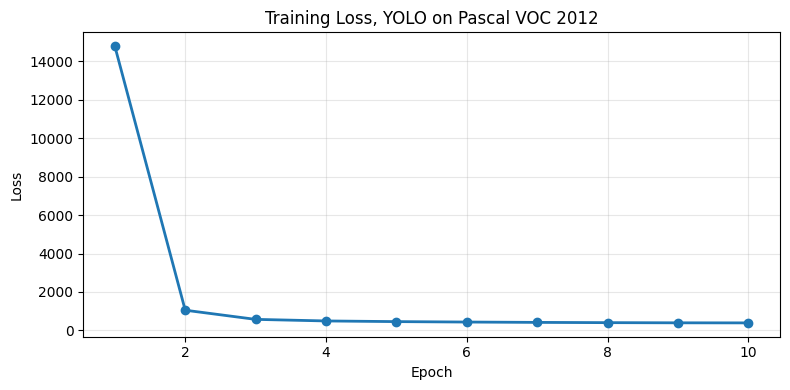

Starting loss : 14786.3447
Final loss    : 390.2919
Reduction     : 97.4%


In [74]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(history) + 1), history, marker='o', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss, YOLO on Pascal VOC 2012')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Starting loss : {history[0]:.4f}")
print(f"Final loss    : {history[-1]:.4f}")
print(f"Reduction     : {(1 - history[-1] / history[0]) * 100:.1f}%")

***
***

# 5 - Detection
## 5 . 1 - Visualization (example)
We run the trained model on a random sample of validation images. The `decode_predictions` function converts the raw output tensor into `[class, confidence, cx, cy, w, h]` tuples, filtering out low-confidence guesses.

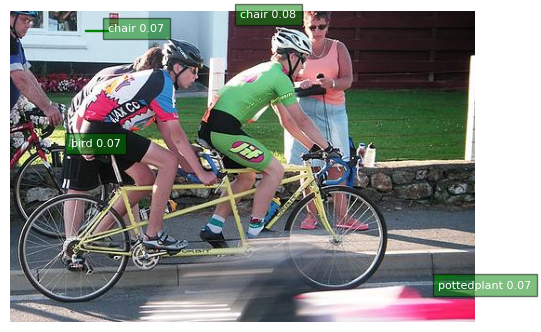

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# Decode YOLO predictions into full-image normalized boxes
def decode_predictions(pred_tensor, S=8, B=3, C=20, conf_threshold=0.75):
    """
    Returns list of [class_id, conf, x_center, y_center, width, height]
    Only boxes with conf >= conf_threshold are returned
    All coordinates normalized to 0-1
    """
    boxes = []
    pred_tensor = pred_tensor.cpu().numpy()
    for i in range(S):
        for j in range(S):
            for b in range(B):
                offset = b*(5+C)
                x_cell, y_cell = pred_tensor[i,j,offset:offset+2]
                w, h = pred_tensor[i,j,offset+2:offset+4]
                conf = pred_tensor[i,j,offset+4]
                class_probs = pred_tensor[i,j,offset+5:offset+5+C]
                class_id = int(class_probs.argmax())
                
                if conf < conf_threshold:
                    continue
                
                # Convert to normalized full-image coordinates
                x = (j + x_cell)/S
                y = (i + y_cell)/S
                boxes.append([class_id, float(conf), float(x), float(y), float(w), float(h)])
    return boxes


def visualize_predictions(image, boxes, class_labels):
    """
    Draw boxes on the image
    image: HWC numpy array in 0-1 range
    boxes: list of [class_id, conf, x, y, w, h] in normalized coordinates
    """
    h, w, _ = image.shape
    plt.figure(figsize=(6,6))
    plt.imshow(image)
    ax = plt.gca()
    
    for box in boxes:
        class_id, conf, x, y, bw, bh = box
        x1 = int((x - bw/2) * w)
        y1 = int((y - bh/2) * h)
        x2 = int((x + bw/2) * w)
        y2 = int((y + bh/2) * h)
        
        # Draw rectangle
        rect = plt.Rectangle((x1, y1), x2-x1, y2-y1, fill=False, edgecolor='green', linewidth=1)
        ax.add_patch(rect)
        
        # Label
        ax.text(
            x1, y1,
            f"{class_labels[class_id]} {conf:.2f}",
            color='white',
            fontsize=8,
            bbox=dict(facecolor='green', alpha=0.5)
        )
    
    plt.axis("off")
    plt.show()

# Pick a sample image
import random
idx = random.randint(0, len(train_dataset) - 1)
image_tensor, _ = train_dataset[idx]

# Convert tensor to numpy for plotting
image = image_tensor.permute(1,2,0).numpy()

# Run model prediction 
image_input = image_tensor.unsqueeze(0).to(device)  # add batch dim
model.eval()
with torch.no_grad():
    pred_tensor = model(image_input)[0]  # remove batch dim

# Decode predictions with low threshold to see rough guesses 
boxes = decode_predictions(pred_tensor, S=16, B=3, C=20, conf_threshold=0.07)
visualize_predictions(image, boxes, VOC_CLASSES)

> **Note:** The visualization above shows how the model's predictions are structured.  
> For this demonstration, the model was trained on a **small subset of the dataset**, with **compressed images**, **fewer convolutional blocks**, **limited neurons**, **reduced parameters**, and **very few training epochs**.  
> As a result, the predicted bounding boxes and class probabilities are **not accurate** and should only be interpreted as a structural example.

## 5 . 2 - Example of prediction 

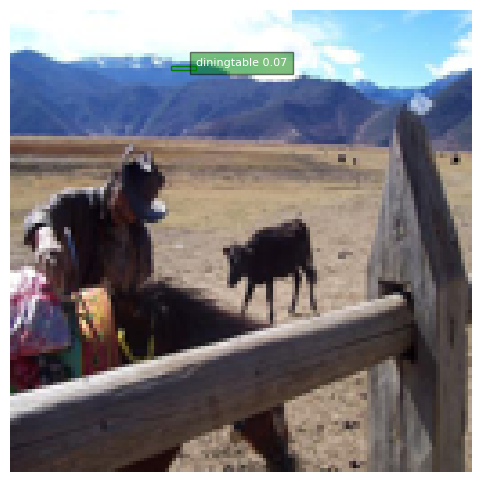

In [ ]:
from PIL import Image

# Load image
image_path = "test_image.jpg"  # replace with your uploaded file path
image_pil = Image.open(image_path).convert("RGB")

# Transform to match model input
transform = T.Compose([
    T.Resize((128, 128)),  # match your training input size
    T.ToTensor()
])
image_tensor = transform(image_pil)  # shape [3, H, W]

# Add batch dimension and send to device
image_input = image_tensor.unsqueeze(0).to(device)  # [1, 3, H, W]

# Run model prediction
model.eval()
with torch.no_grad():
    pred_tensor = model(image_input)[0]  # remove batch dim

# Convert PIL image to numpy for plotting
image_np = np.array(image_pil.resize((128, 128)))/255.0  # normalize to 0-1

# Decode predictions
boxes = decode_predictions(pred_tensor, S=16, B=3, C=20, conf_threshold=0.07)

# Visualize
visualize_predictions(image_np, boxes, VOC_CLASSES)

***
***
# 6 - Evaluation
## 6 . 1 - Loss on the training set 

In [78]:
model.eval()  # Set model to evaluation mode
total_loss = 0
num_batches = 0

with torch.no_grad():  # no gradients needed
    for images, targets in train_loader:
        images = images.to(device)
        # encode targets to match YOLO output shape
        targets_batch = torch.stack([encode_target(t, S=16, B=3, C=20) for t in targets]).to(device)

        predictions = model(images)
        loss = YOLO_loss(predictions, targets_batch)

        total_loss += loss.item()
        num_batches += 1

mean_loss = total_loss / num_batches
print(f"Mean YOLO loss on training set: {mean_loss:.4f}")

Mean YOLO loss on training set: 259.5188


## 6 . 2 - Loss on validation set 

In [86]:
val_transforms = T.Compose([
    T.ToPILImage(),
    T.Resize((128, 128)),       
    T.ToTensor()
])

val_dataset = YOLODataset(
    img_dir="Pascal VOC 2012.v1/valid/images",
    label_dir="Pascal VOC 2012.v1/valid/labels",
    transforms=val_transforms
)

val_dataset.images = random.sample(val_dataset.images, HPARAMS['subset_size'])

val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False, collate_fn=collate_fn)

model.eval()  # Set model to evaluation mode
total_loss = 0
num_batches = 0

with torch.no_grad():  # no gradients needed
    for images, targets in val_loader:
        images = images.to(device)
        # encode targets to match YOLO output shape
        targets_batch = torch.stack([encode_target(t, S=16, B=3, C=20) for t in targets]).to(device)

        predictions = model(images)
        loss = YOLO_loss(predictions, targets_batch)

        total_loss += loss.item()
        num_batches += 1

mean_loss = total_loss / num_batches
print(f"Mean YOLO loss on validation set: {mean_loss:.4f}")

Mean YOLO loss on validation set: 264.6788


## 6 . 3 - Loss on augmented training set 

In [90]:
import copy

aug_transforms = T.Compose([
    T.ToPILImage(),
    T.Resize((128, 128)),       
    T.ColorJitter(brightness=0.2, contrast=0.2),    # Augmentation
    T.ToTensor()
])

aug_train_dataset = copy.deepcopy(val_dataset)
aug_train_dataset.transforms = aug_transforms
aug_train_loader = torch.utils.data.DataLoader(
    aug_train_dataset, batch_size=4, shuffle=False, collate_fn=collate_fn
)

model.eval()
total_loss = 0
num_batches = 0

with torch.no_grad():
    for images, targets in aug_train_loader:
        images = images.to(device)
        # **S matches model.grid_size**
        targets_batch = torch.stack([encode_target(t) for t in targets]).to(device)

        predictions = model(images)
        loss = YOLO_loss(predictions, targets_batch)

        total_loss += loss.item()
        num_batches += 1

mean_loss = total_loss / num_batches
print(f"Mean YOLO loss on augmented training set: {mean_loss:.4f}")

Mean YOLO loss on augmented training set: 132.5519
